In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#My dataset talks about trying to find a different way to diagnose parkinsons disease because it is so expensive and takes a lot of time. 
#Parkinsons is tracked by using the Parkinson's disease rating scale (UPDRS). Vocal impairment is often one of the most common symptoms 
#but also one of the symptoms that worsens as the disease progresses.

#This question must be answered at some point in your notebook through dataset exploration
#Is there a correlation between vocal instability and Parkinsons?

#1.Load the dataset. Print the shape, Display first few rows. 
file = "parkinsons_updrs.data"
df = pd.read_csv(file)
print(df.shape)

#first five rows
print(df.iloc[:5])

#choosing two columns Jitter(abs): The variation of of the voice frequency and then motor_UPDRS: Parkinsons motor symptom severity. 
#Paper talks about how as disease worsens the speech instability increases
j_abs = df["Jitter(Abs)"]
updrs = df["motor_UPDRS"]




(5875, 22)
   subject#  age  sex  test_time  motor_UPDRS  total_UPDRS  Jitter(%)  \
0         1   72    0     5.6431       28.199       34.398    0.00662   
1         1   72    0    12.6660       28.447       34.894    0.00300   
2         1   72    0    19.6810       28.695       35.389    0.00481   
3         1   72    0    25.6470       28.905       35.810    0.00528   
4         1   72    0    33.6420       29.187       36.375    0.00335   

   Jitter(Abs)  Jitter:RAP  Jitter:PPQ5  ...  Shimmer(dB)  Shimmer:APQ3  \
0     0.000034     0.00401      0.00317  ...        0.230       0.01438   
1     0.000017     0.00132      0.00150  ...        0.179       0.00994   
2     0.000025     0.00205      0.00208  ...        0.181       0.00734   
3     0.000027     0.00191      0.00264  ...        0.327       0.01106   
4     0.000020     0.00093      0.00130  ...        0.176       0.00679   

   Shimmer:APQ5  Shimmer:APQ11  Shimmer:DDA       NHR     HNR     RPDE  \
0       0.01309        0.

In [ ]:
#2 a for loop running counter (comment out what is countng has to be meaninful)

#Count how many patients are high severity in motor_updrs
hs_patients = 0
moderate=df.loc[111,"motor_UPDRS"]

for num in updrs:
    if num > moderate:
        hs_patients += 1

print(f"There are {hs_patients} high severity patients")


There are 757 high severity patients


In [ ]:
#3 and 4) Conditional Logic(use an if/elif/else block somewhere in your analysis)
#4) Write and call your own function that takes parameters and returns a value

mild = df.loc[169,"motor_UPDRS"]
#15.7
moderate=df.loc[111,"motor_UPDRS"]
#30.7

def test_severity(score):
    #test the severity of the parkinsons disease based on a value of motor_UPDRS and returns if
    #score under 15.7 are mild and under 30.7 they are moderate disease progression but anything else is severe
    if score < mild:
        severity_level = 'Mild'
        return(severity_level)
    elif score < moderate:
        severity_level = "Moderate"
        return severity_level
    else:
        severity_level = 'Severe'
        return severity_level
    
mild_test=df.loc[161,"motor_UPDRS"]
moderate_test=df.loc[0,"motor_UPDRS"]
severe_test=df.loc[141,"motor_UPDRS"]

print(mild_test,moderate_test,severe_test)
print(test_severity(mild_test),test_severity(moderate_test),test_severity(severe_test))



12.834 28.199 33.643
Mild Moderate Severe


In [24]:
#5) Numpy array indexing (sum,mean and indexing)
j_arr = np.array(j_abs)

print("Mean:", np.mean(j_arr))
print("Mean + 2:", np.mean(j_arr) + 2)

#Get third row of jitter array which is 2.462e-05
t=j_arr[:3]

print(j_arr[2])
print(t[-1])

Mean: 4.4027118297872336e-05
Mean + 2: 2.0000440271182978
2.462e-05
2.462e-05


In [ ]:
#6) Build a Dictionary (Read directly using square brackets)
#Dictionary that counts how many cases of mild,moderate,and severe there are. 

storing_dict= {
    "Mild": 0,
    "Moderate": 0, 
    'Severe': 0
             }


for num in updrs:
    if num < mild:
        storing_dict['Mild'] +=1
    elif num < moderate:
        storing_dict['Moderate'] +=1
    else:
        storing_dict['Severe'] +=1
print(storing_dict['Mild'])
print(storing_dict['Moderate'])
print(storing_dict['Severe'])


1936
3176
763


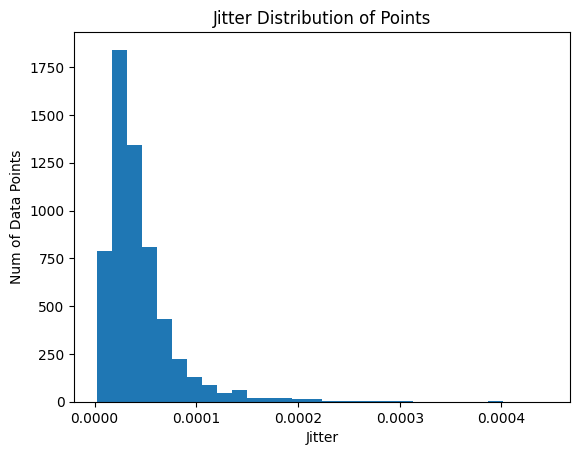

Text(0, 0.5, 'motor_UPDRS')

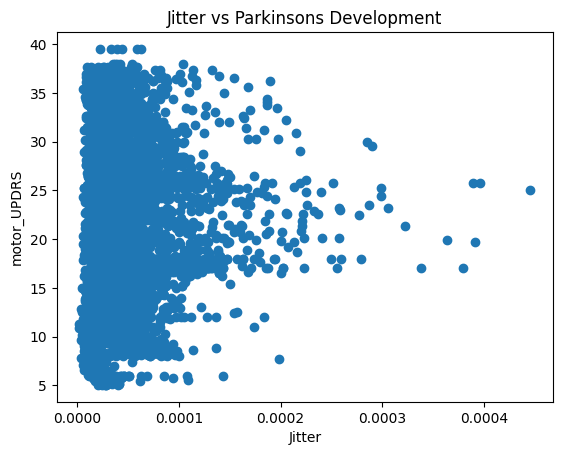

In [ ]:
#7) Two plots with matplotlib (Produce at least two distinct plots using matplotlib. Every plot must have axis labels and a title.)
#Histogram of numeric column meaningful bin count and label the axes with units comment shape
plt.hist(j_abs, bins=30)
plt.xlabel("Jitter")
plt.ylabel("Num of Data Points")
plt.title("Jitter Distribution of Points")
plt.show()
#distrubution skewed to the right 

#Choosing scatter because I believe it best answers my question from the beggining
#Seeing Is there a correlation between vocal instability and Parkinsons disease development
#choosing two columns Jitter(abs): The variation of of the voice frequency and then motor_UPDRS: Parkinsons motor symptom severity. 
plt.scatter(j_abs,updrs)
plt.title("Jitter vs Parkinsons Development")
plt.xlabel("Jitter")
plt.ylabel("motor_UPDRS")



From my graphs it shows most of the data is clustered and doesnt show a linear relationship. Patients with low jitter are throughout and span the entire range of UPDRS scores so low jitter doesnt guarentee mild disease progression. At high jitter they are mainly in the moderate range of UPDRS score where  originally predictted that as high jitter increases so does the disease progression score. So there is not enough proof that vocal instability and Parkinsons disease development are related. 